In [2]:
import json, random
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

LABEL_PATH  = '/content/drive/MyDrive/lung_sound/processed/labels.json'
OUTPUT_PATH = '/content/drive/MyDrive/lung_sound/processed/split_labels.json'
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
LABEL_NAMES = ['정상', '비정상']

with open(LABEL_PATH, 'r') as f:
    all_labels = json.load(f)
print(f'전체 샘플 수: {len(all_labels)}')

class_files = {0: [], 1: []}
for item in all_labels:
    class_files[item['label']].append(item['file'])

train_list, val_list, test_list = [], [], []
for label, files in class_files.items():
    random.shuffle(files)
    n = len(files)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    train_list += [{'file': f, 'label': label} for f in files[:n_train]]
    val_list   += [{'file': f, 'label': label} for f in files[n_train:n_train+n_val]]
    test_list  += [{'file': f, 'label': label} for f in files[n_train+n_val:]]

print(f'Train: {len(train_list)}, Val: {len(val_list)}, Test: {len(test_list)}')

split_labels = {'train': train_list, 'val': val_list, 'test': test_list}
with open(OUTPUT_PATH, 'w') as f:
    json.dump(split_labels, f)
print('저장 완료!')

Mounted at /content/drive
전체 샘플 수: 3901
Train: 2730, Val: 584, Test: 587
저장 완료!


In [4]:
!apt-get install -y fonts-nanum -q
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [5]:
import json, random
from pathlib import Path

LABEL_PATH  = '/content/drive/MyDrive/lung_sound/processed/labels.json'
OUTPUT_PATH = '/content/drive/MyDrive/lung_sound/processed/split_labels.json'
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
LABEL_NAMES = ['정상', '비정상']

random.seed(42)  # 재현성을 위한 시드 고정

with open(LABEL_PATH, 'r') as f:
    all_labels = json.load(f)
print(f'전체 샘플 수: {len(all_labels)}')

class_files = {0: [], 1: []}
for item in all_labels:
    class_files[item['label']].append(item['file'])

train_list, val_list, test_list = [], [], []
for label, files in class_files.items():
    random.shuffle(files)
    n = len(files)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    train_list += [{'file': f, 'label': label} for f in files[:n_train]]
    val_list   += [{'file': f, 'label': label} for f in files[n_train:n_train+n_val]]
    test_list  += [{'file': f, 'label': label} for f in files[n_train+n_val:]]

print(f'Train: {len(train_list)}, Val: {len(val_list)}, Test: {len(test_list)}')

split_labels = {'train': train_list, 'val': val_list, 'test': test_list}
with open(OUTPUT_PATH, 'w') as f:
    json.dump(split_labels, f)
print('저장 완료!')

전체 샘플 수: 3901
Train: 2730, Val: 584, Test: 587
저장 완료!


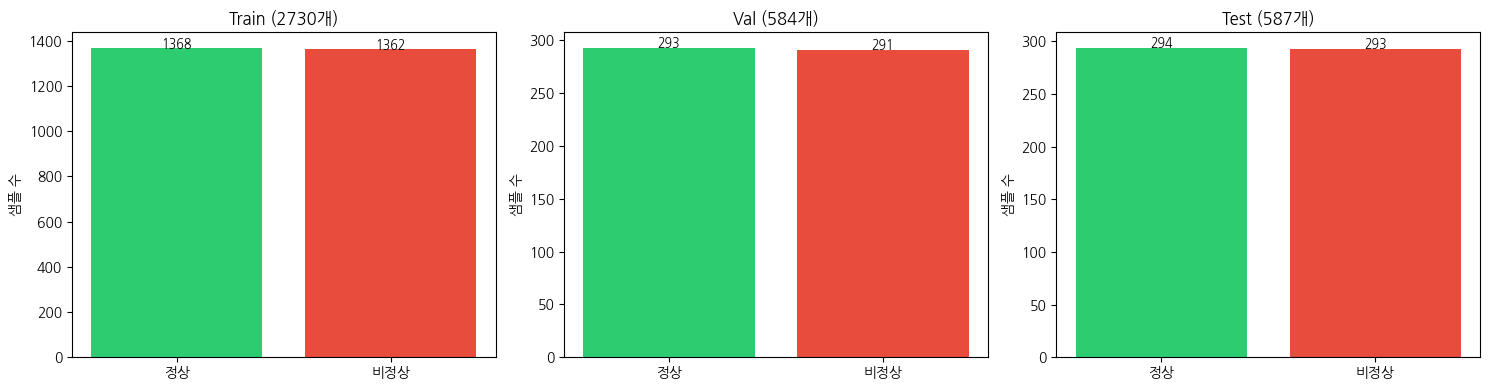

In [6]:
# 클래스 분포 막대그래프
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (split_name, split_data) in zip(axes, [('Train', train_list), ('Val', val_list), ('Test', test_list)]):
    counts = [0, 0]
    for item in split_data:
        counts[item['label']] += 1
    bars = ax.bar(LABEL_NAMES, counts, color=['#2ecc71', '#e74c3c'])
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontsize=9)
    ax.set_title(f'{split_name} ({len(split_data)}개)')
    ax.set_ylabel('샘플 수')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lung_sound/split_distribution_final.png', dpi=150, bbox_inches='tight')
plt.show()